In [3]:
%pip install pennylane

  Using cached pennylane-0.44.1-py3-none-any.whl.metadata (12 kB)
  Using cached autograd-1.8.0-py3-none-any.whl.metadata (7.5 kB)
  Using cached appdirs-1.4.4-py2.py3-none-any.whl.metadata (9.0 kB)
  Using cached autoray-0.8.2-py3-none-any.whl.metadata (6.1 kB)
  Using cached cachetools-7.0.6-py3-none-any.whl.metadata (5.9 kB)
  Using cached tomlkit-0.14.0-py3-none-any.whl.metadata (2.8 kB)
  Using cached diastatic_malt-2.15.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached scipy_openblas32-0.3.31.188.0-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (57 kB)
Using cached pennylane-0.44.1-py3-none-any.whl (5.3 MB)
Using cached autoray-0.8.2-py3-none-any.whl (935 kB)
Using cached diastatic_malt-2.15.2-py3-none-any.whl (167 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5

# PennyLane 101
1. Quantum functions and QNodes
2. Devices
3. Templates
4. Debugging tips

In [1]:
# import your new favourite library
import pennylane as qp

qp.about()
# Go to pennylane.ai to see if you're using the recent stable version

Name: pennylane
Version: 0.44.1
Summary: PennyLane is a cross-platform Python library for quantum computing, quantum machine learning, and quantum chemistry. Train a quantum computer the same way as a neural network.
Home-page: 
Author: 
License: 
Location: /home/jovyan/.qbraid/environments/69qe/pyenv/lib/python3.12/site-packages
Platform info:           Linux-6.12.55+-x86_64-with-glibc2.35
Python version:          3.12.13
Numpy version:           2.3.5
Scipy version:           1.17.0
JAX version:             None
Installed devices:
- lightning.qubit (pennylane_lightning-0.44.0)
- default.clifford (pennylane-0.44.1)
- default.gaussian (pennylane-0.44.1)
- default.mixed (pennylane-0.44.1)
- default.qubit (pennylane-0.44.1)
- default.qutrit (pennylane-0.44.1)
- default.qutrit.mixed (pennylane-0.44.1)
- default.tensor (pennylane-0.44.1)
- null.qubit (pennylane-0.44.1)
- reference.qubit (pennylane-0.44.1)


# Quantum function and Qnodes
A quantum function is just a Python function that includes quantum gates and a measurement

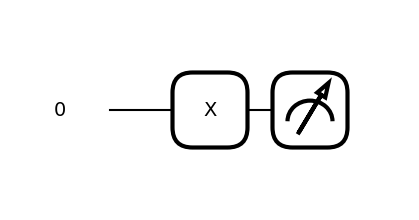

In [3]:
# This is a quantum function
def circuit():
    qp.X(wires=0)
    return qp.probs()

qp.draw_mpl(circuit)();

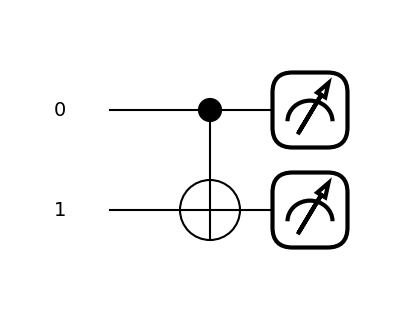

In [4]:
# This is also a quantum function
def circuit2():
    qp.CNOT(wires=[0,1])
    return qp.probs()

qp.draw_mpl(circuit2)();

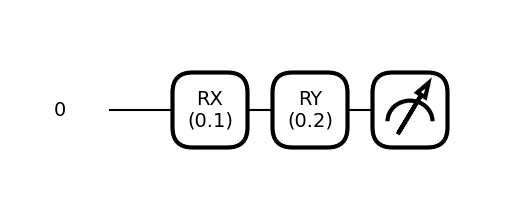

In [7]:
# This is a quantum function where the gates take parameters
def circuit():
    qp.RX(0.1,wires=0)
    qp.RY(0.2,wires=0)
    return qp.probs()

qp.draw_mpl(circuit, decimals=1)();

 QNodes allow you to run your quantum function on a specific device (simulator or actual quantum hardware).
 
 Tip: Not everthing needs to be a qnode, sometimes quantum functions are enough.

array([0.98758516, 0.01241484])

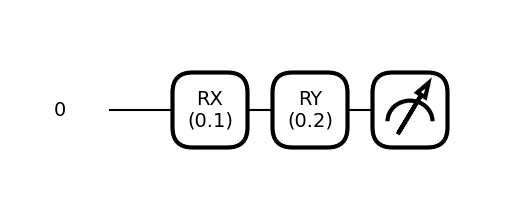

In [10]:
# device
dev = qp.device("default.qubit")

# This is a qnode
qnode1 = qp.QNode(circuit,dev)

# This is also a qnode (this is preferred way to create a qnode)
@qp.qnode(dev)
def circuit(x,y):
    qp.RX(x,wires=0)
    qp.RY(y,wires=0)
    return qp.probs()

# Run your circuit by simply calling the function
qp.draw_mpl(circuit,decimals=1)(0.1,0.2);

circuit(0.1,0.2)

 The output tells us that there's over 90% chance to measure our qubit in the |0> state and only a small chance of measuring our qubit in the |1> state.

# Devices
    Tip: lightning.qubit and default.qubit are usually a sefe bet.

In [12]:
# Go to pennylane.ai/performance#which-simulator to learn about different devices
# Prioritize default.qubit for small simulations or lightning.qubit for larger ones

dev = qp.device("default.qubit")

# When using default.qubit you don't need to speccify the wires (number of qubits)
# When using other devices you do need to specify the wires

dev_l = qp.device("lightning.qubit",wires=3)

# Templates

Find them in the docs : https://docs.pennylane.ai/en/stable/introduction/templates.html

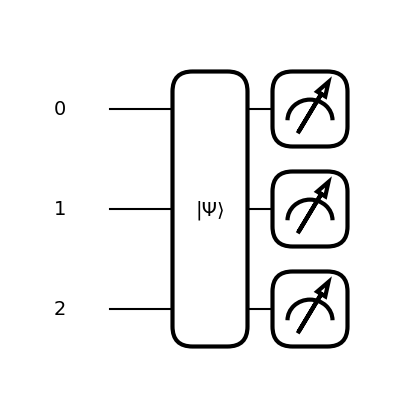

In [14]:
# Create a qnode
@qp.qnode(dev_l)
def circuit():

    # add the template within the function and apply it on a specific set of wires
    qp.BasisEmbedding([1,1,0],wires=[0,1,2])
    
    # return a measurement
    return qp.probs()
    
# Draw your circuit
qp.draw_mpl(circuit)();

array([0., 0., 0., 0., 0., 0., 1., 0.])

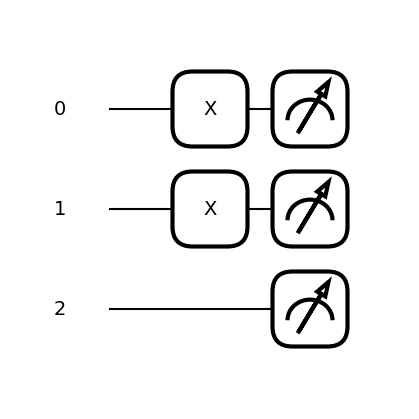

In [16]:
# You can decompose the template into gates
circuit2 = qp.transforms.decompose(circuit)

# Draw your circuit
qp.draw_mpl(circuit2, show_all_wires=True)();

# Run your circuit
circuit2()
